In [9]:
import numpy as np
import pandas as pd
import os
import string
import scipy.io as spio
import pandapower as pp
from pandapower.plotting.plotly import simple_plotly
from pandapower.plotting.plotly import vlevel_plotly
import pathlib
from importlib import resources
from tqdm import tqdm

cwd = pathlib.Path.cwd()
import plotly.express as px

np.set_printoptions(linewidth=100)

# Resources
- OPF: Optimal Power Flow. **A good introduction is provided here**: https://invenia.github.io/blog/2021/06/18/opf-intro/
- PF: Power Flow. **A good introduction is provided here**: https://invenia.github.io/blog/2020/12/04/pf-intro/
- pandapower documentation: https://pandapower.readthedocs.io/en/v2.0.0/index.html




# Nomenclature
- This is not best practice, but I often use the words "demand", "load", and "consumption" interchangeably to mean the amount of electrical power required.
- I sometimes refer to electrical "buses" as "nodes"

# Loading the network

- We first load the network in pandapower.
- The list of available networks in pandapower is here: https://pandapower.readthedocs.io/en/v2.0.0/networks/power_system_test_cases.html#case-gb-reduced-network

- Here, we load the 24-bus IEEE system
- IEEE test systems, like the IEEE 24-bus system, are simplified models of power grids used to test and compare methods for PF and OPF. These systems are introduced here: https://arxiv.org/pdf/1908.02788








In [6]:
import os
import pandapower as pp
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

# Root directory to search in all subfolders
root_path = 'Swiss-PDGs-v1.0/aeonetos-Swiss-PDGs-3354b4d/grids/pandapower_data/'

# Collect all .xlsx file paths in all subdirectories
xlsx_files = []
for dirpath, dirnames, filenames in os.walk(root_path):
    for file in filenames:
        if file.endswith('.xlsx'):
            xlsx_files.append(os.path.join(dirpath, file))

In [9]:
# Initialize lists to store results
all_vm_pu = []
all_va_degree = []

# Process each file with a progress bar
for filepath in tqdm(xlsx_files, desc="Processing All Grids"):
    try:
        net = pp.from_excel(filepath)
        if not net.gen.empty or not net.sgen.empty:
            print("Generator found in ", filepath)
        # pp.runpp(net)
        # all_vm_pu.extend(net.res_bus.vm_pu.values)
        # all_va_degree.extend(net.res_bus.va_degree.values)
    except Exception as e:
        print(f"⚠️ Error in {filepath}: {e}")

Processing All Grids:  79%|███████▊  | 28107/35801 [1:18:06<21:12,  6.05it/s]   

⚠️ Error in Swiss-PDGs-v1.0/aeonetos-Swiss-PDGs-3354b4d/grids/pandapower_data/LV\Midlands-Urban\2701-313_0_4_grid.xlsx: File is not a zip file


Processing All Grids: 100%|██████████| 35801/35801 [1:46:27<00:00,  5.60it/s]


In [3]:
# Convert to Series
vm_series = pd.Series(all_vm_pu)
va_series = pd.Series(all_va_degree)

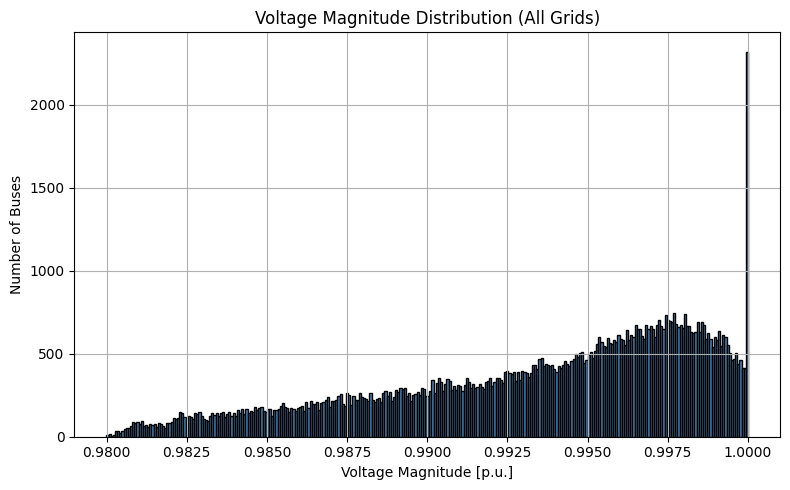

In [11]:
# Plot voltage magnitude distribution
plt.figure(figsize=(8, 5))
plt.hist(vm_series, bins=300, color='steelblue', edgecolor='black')
plt.title("Voltage Magnitude Distribution (All Grids)")
plt.xlabel("Voltage Magnitude [p.u.]")
plt.ylabel("Number of Buses")
plt.grid(True)
plt.tight_layout()
plt.show()

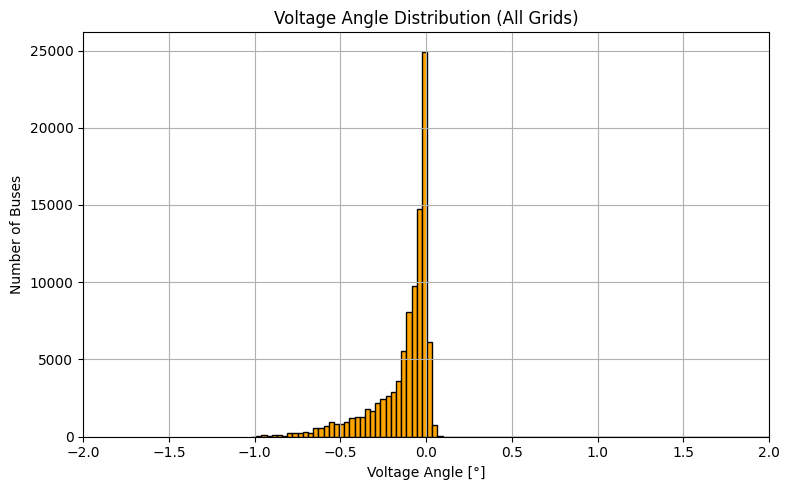

In [ ]:
# Plot voltage angle distribution
plt.figure(figsize=(8, 5))
plt.hist(va_series, bins=300, color='orange', edgecolor='black')
plt.title("Voltage Angle Distribution (All Grids)")
plt.xlabel("Voltage Angle [°]")
plt.ylabel("Number of Buses")
plt.xlim(-2, 2)
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
import pandapower as pp
net = pp.from_excel('Swiss-PDGs-v1.0/aeonetos-Swiss-PDGs-3354b4d/grids/pandapower_data/MV/1_0_grid.xlsx')


In [7]:
pp.runpp(net)

In [8]:
net['_ppc']

{'baseMVA': 1,
 'version': 2,
 'bus': array([[0.00000000e+00, 1.00000000e+00, 3.72773413e-01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [1.76000000e+02, 1.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.77000000e+02, 1.00000000e+00, 7.84179971e-02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.78000000e+02, 1.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]),
 'branch': array([[0.00000000e+00+0.j, 1.00000000e+00+0.j, 2.27717625e-05+0.j, ...,
         0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j],
        [1.00000000e+00+0.j, 2.00000000e+00+0.j, 5.98077311e-04+0.j, ...,


In [5]:
net.gen.empty

True

In [6]:
pp.runpp(net)

In [9]:
net


This pandapower network includes the following parameter tables:
   - bus (197 elements)
   - load (158 elements)
   - ext_grid (1 element)
   - line (195 elements)
   - trafo (1 element)
   - line_geodata (195 elements)
   - bus_geodata (197 elements)
 and the following results tables:
   - res_bus (197 elements)
   - res_line (195 elements)
   - res_trafo (1 element)
   - res_ext_grid (1 element)
   - res_load (158 elements)

In [46]:
net.load.p_mw = net.load.p_mw * 4

In [61]:
pp.runpp(net)

In [62]:
net.bus.head()

,name,vn_kv,type,zone,in_service
0,bus_LV_572-1_0_6_node_0,0.4,n,None,True
1,bus_LV_572-1_0_6_node_1,0.4,n,None,True
2,bus_LV_572-1_0_6_node_2,0.4,n,None,True
3,bus_LV_572-1_0_6_node_3,0.4,n,None,True
4,bus_LV_572-1_0_6_node_4,0.4,n,None,True


In [64]:
net.res_bus.head()

,vm_pu,va_degree,p_mw,q_mvar
0,0.993887,-0.116057,0.010284,0.002578
1,0.994085,-0.112279,0.002624,0.000658
2,0.990447,-0.182138,0.001342,0.000336
3,0.995596,-0.083378,0.000000,0.000000
4,0.988697,-0.215939,0.000000,0.000000


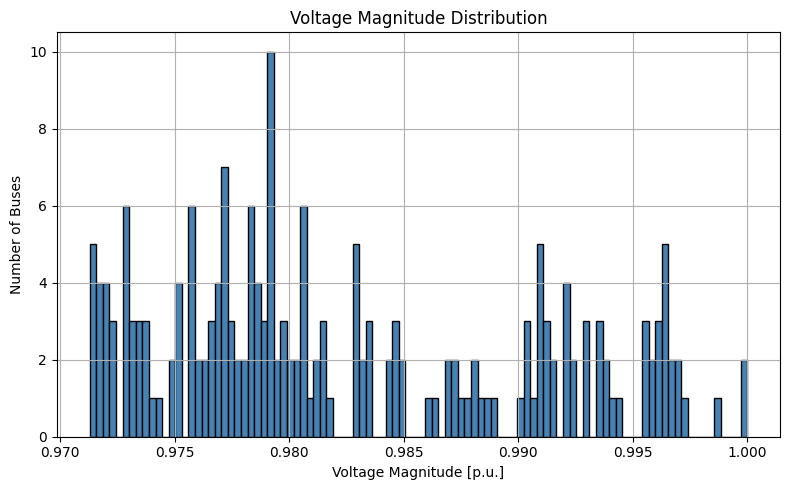

In [65]:
import pandapower as pp
import matplotlib.pyplot as plt

# Assuming 'net' is your pandapower network with results
vm_pu = net.res_bus.vm_pu

plt.figure(figsize=(8, 5))
plt.hist(vm_pu, bins=100, color='steelblue', edgecolor='black')
plt.title("Voltage Magnitude Distribution")
plt.xlabel("Voltage Magnitude [p.u.]")
plt.ylabel("Number of Buses")
plt.grid(True)
plt.tight_layout()
plt.show()


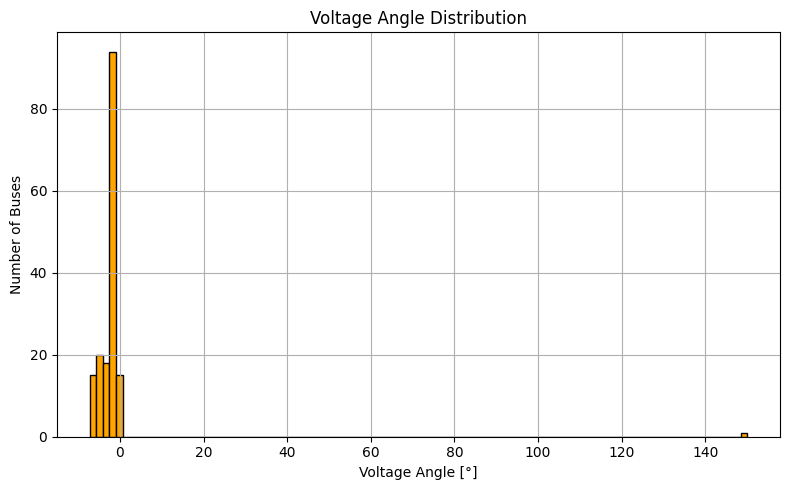

In [55]:
va_degree = net.res_bus.va_degree

plt.figure(figsize=(8, 5))
plt.hist(va_degree, bins=100, color='orange', edgecolor='black')
plt.title("Voltage Angle Distribution")
plt.xlabel("Voltage Angle [°]")
plt.ylabel("Number of Buses")
plt.grid(True)
plt.tight_layout()
plt.show()


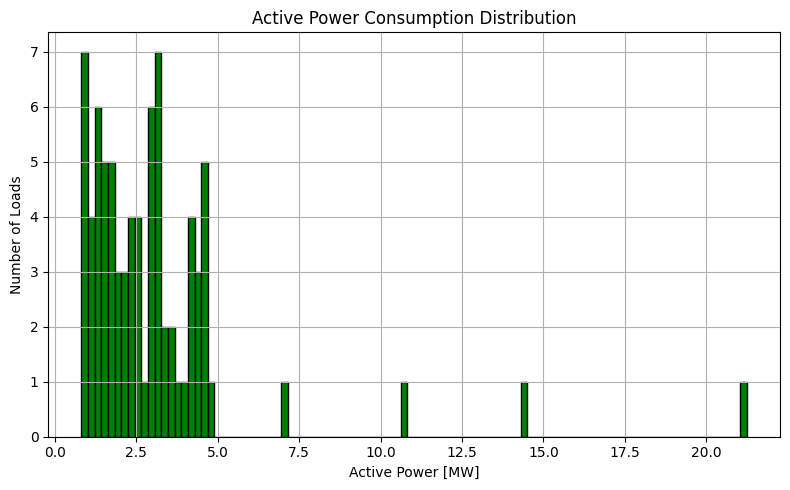

In [57]:
p_mw = net.res_load.p_mw

plt.figure(figsize=(8, 5))
plt.hist(p_mw, bins=100, color='green', edgecolor='black')
plt.title("Active Power Consumption Distribution")
plt.xlabel("Active Power [MW]")
plt.ylabel("Number of Loads")
plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
net

This pandapower network includes the following parameter tables:
   - bus (144 elements)
   - load (95 elements)
   - ext_grid (1 element)
   - line (142 elements)
   - trafo (1 element)
   - line_geodata (142 elements)
   - bus_geodata (144 elements)
 and the following results tables:
   - res_bus (144 elements)
   - res_line (142 elements)
   - res_trafo (1 element)
   - res_ext_grid (1 element)
   - res_load (95 elements)

In [5]:
pp.runpp(net)

In [21]:
net.sn_mva

1

- We load the demand profile which is obtained from powergraph  https://github.com/PowerGraph-Datasets/PowerGraph-Node
- Make sure you load the right demand profile for the network you are considering. Powergraph has load profiles for IEEE118, IEEE24, IEEE39, UK, and the name of these networks is slightly different in pandapower.



# Overview of different pandapower `net` dataframes

- pandapower stores the network data in different dataframes. We will take a look at some of them below
- Initially, the load and generation information is the one coming from the grid case file we have loaded

## Load

- `net.load` contains all load elements in the grid. Each bus can have 0 or max 1 load. The properties of the load elements include:
    - `p_mw` is the active power demand
    - `q_mvar` is the reactive power demand
    - the column `bus` indicates the bus the loads are connected to

In [7]:
net.load

,name,bus,p_mw,q_mvar,const_z_percent,const_i_percent,sn_mva,scaling,in_service,type
0,LV_111-1_0_3_load_0,0,0.000473,0.000119,0.0,0.0,NaN,1.0,True,wye
1,LV_111-1_0_3_load_1,1,0.000771,0.000193,0.0,0.0,NaN,1.0,True,wye
2,LV_111-1_0_3_load_311,2,0.000533,0.000134,0.0,0.0,NaN,1.0,True,wye
3,LV_111-1_0_3_load_9,3,0.000521,0.000131,0.0,0.0,NaN,1.0,True,wye
4,LV_111-1_0_3_load_10,4,0.001434,0.000359,0.0,0.0,NaN,1.0,True,wye
5,LV_111-1_0_3_load_12,6,0.000731,0.000183,0.0,0.0,NaN,1.0,True,wye
6,LV_111-1_0_3_load_337,7,0.000121,0.000030,0.0,0.0,NaN,1.0,True,wye
7,LV_111-1_0_3_load_15,8,0.000109,0.000027,0.0,0.0,NaN,1.0,True,wye
8,LV_111-1_0_3_load_13,9,0.000319,0.000080,0.0,0.0,NaN,1.0,True,wye
9,LV_111-1_0_3_load_16,10,0.001339,0.000336,0.0,0.0,NaN,1.0,True,wye


## Generators (`gen`)

Same as above, but:
- `p_mw` is the active power generated 
- there is no reactive power info before we run OPF
- `min_p_mw`, `max_p_mw`, `min_q_mvar`, `max_q_mvar` are bounds on the active (reactive) power generated 
- `vm_pu` is the voltage in per unit


In [8]:
net.gen

,name,bus,p_mw,vm_pu,sn_mva,min_q_mvar,max_q_mvar,scaling,slack,in_service,slack_weight,type


## Static generators (`sgen`)

In pandapower, static generators (`sgen`s) inject active and reactive power into the grid but don’t have a voltage control variable, meaning their output doesn’t directly regulate bus voltage like a traditional generator.

In [9]:
net.sgen

,name,bus,p_mw,q_mvar,sn_mva,scaling,in_service,type,current_source


## REF/ Slack

- The slack (aka. "ref") bus is a reference node in the system used to balance the active and reactive power in the grid
- In pandapower, the `ext_grid` element is connected to the slack bus and plays this role. it has fixed voltage and phase angle, and the system can draw or get power from it to maintain balance.

In [10]:
net.ext_grid

,name,bus,vm_pu,va_degree,slack_weight,in_service
0,None,14,1.0,0.0,1.0,True


## Shunts

- Shunts are other elements used to balance the active and reactive power in the grid.
- Think of them as "controllable" loads

In [11]:
net.shunt

,bus,name,q_mvar,p_mw,vn_kv,step,max_step,in_service


## Lines

Lines connect buses
- `r_ohm_per_km` and `x_ohm_per_km`: Line resistance and reactance.
- `max_i_ka`: max current capacity

In [12]:
net.line

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service
0,LV_111-1_0_3_line_0,None,0,1,0.107966,0.125,0.08,261.0,0.0,0.364,1.0,1,cs,True
1,LV_111-1_0_3_line_1,None,0,2,0.178084,0.125,0.08,261.0,0.0,0.364,1.0,1,cs,True
2,LV_111-1_0_3_line_2,None,2,12,0.207136,0.125,0.08,261.0,0.0,0.364,1.0,1,cs,True
3,LV_111-1_0_3_line_3,None,3,4,0.032918,0.125,0.08,261.0,0.0,0.364,1.0,1,cs,True
4,LV_111-1_0_3_line_4,None,3,5,0.034390,0.125,0.08,261.0,0.0,0.364,1.0,1,cs,True
5,LV_111-1_0_3_line_5,None,4,6,0.023610,0.125,0.08,261.0,0.0,0.364,1.0,1,cs,True
6,LV_111-1_0_3_line_6,None,5,7,0.213383,0.125,0.08,261.0,0.0,0.364,1.0,1,cs,True
7,LV_111-1_0_3_line_7,None,6,8,0.200689,0.125,0.08,261.0,0.0,0.364,1.0,1,cs,True
8,LV_111-1_0_3_line_8,None,7,110,0.015767,0.125,0.08,261.0,0.0,0.364,1.0,1,cs,True
9,LV_111-1_0_3_line_9,None,8,9,0.231644,0.125,0.08,261.0,0.0,0.364,1.0,1,cs,True


## Transformers 

In [13]:
net.trafo

,name,std_type,hv_bus,lv_bus,sn_mva,vn_hv_kv,vn_lv_kv,vk_percent,vkr_percent,pfe_kw,i0_percent,shift_degree,tap_side,tap_neutral,tap_min,tap_max,tap_step_percent,tap_step_degree,tap_pos,tap_phase_shifter,parallel,df,in_service
0,LV_111-1_0_3_trafo_313,0.63 MVA 20/0.4 kV,118,14,0.63,20.0,0.4,6.0,1.206,1.65,0.2619,150.0,hv,0,-2,2,2.5,0.0,0,False,1,1.0,True


## poly cost

`net.polycost` stores the different terms of the generation cost function

At every `gen` or `sgen` element, we have:
$$C(p_{\text{MW}}, q_{\text{MVar}}) = cp_0 + cp_1 \cdot p_{\text{MW}} + cp_2 \cdot p_{\text{MW}}^2 + cq_0 + cq_1 \cdot q_{\text{MVar}} + cq_2 \cdot q_{\text{MVar}}^2$$



In [14]:
net.poly_cost

,element,et,cp0_eur,cp1_eur_per_mw,cp2_eur_per_mw2,cq0_eur,cq1_eur_per_mvar,cq2_eur_per_mvar2


## Bus types

- **PV** Buses: connected to `gen`s, `sgen`s, and sometimes also `load`s
- **PQ** Buses: connected to `load`s (or nothing) and/or `shunt`s. Can **not** be connected to generation elements like `gen`, `sgen` or `ext_grid`
- Slack/ REF Bus: connected to `ext_grid`. Can also be connected to any other element  


In [16]:
net

This pandapower network includes the following parameter tables:
   - bus (119 elements)
   - load (86 elements)
   - ext_grid (1 element)
   - line (117 elements)
   - trafo (1 element)
   - line_geodata (117 elements)
   - bus_geodata (119 elements)
 and the following results tables:
   - res_bus (119 elements)
   - res_line (117 elements)
   - res_trafo (1 element)
   - res_ext_grid (1 element)
   - res_load (86 elements)

Note that there are PQ buses which dont have any load (nor generator element, by definition)

In [ ]:
(net.bus["type"] == PQ).sum()  # number of PQ buses

In [ ]:
net.load[net.load.type == PQ].bus.nunique()  # number of PQ buses with loads

## Viz

I keep this here but I am not sure it is useful...

In [ ]:
# Quick Visualization of the loaded Grid (Matplotlib Version)
pp.plotting.simple_plot(net)

# Loading the load scenarios

We first get the load scenarios from the scenario file, the path to which we defined earlier:

In [75]:
scenarios = load_scenario_from_file(net, demand_file) 

Note that these load scenarios show many limitations. Among others, the load fluctuations over time is the same accross all buses... -> the load variations are not independent accross buses ;)

In [ ]:
df = pd.DataFrame(scenarios[:5, :].T, columns=[f"Bus {i+1}" for i in range(5)])

# Create the line plot with a legend
fig = px.line(df, title="Time Series of the Load for the First 5 Buses")
fig.update_layout(
    xaxis_title="Time Steps",
    yaxis_title="Load",
    legend_title="Buses"
)
fig.show()


- We now replace the default active power load from the case file by the active power load of the **first load scenario** (in this notebook, we will only solve one OPF/PF problem, i.e. look at one time-snapshot of the grid). 
- Note that the **reactive power is not changed** (as it is the case in the approach used by powergraph) -> we should improve this in the future


In [77]:
#  set demand at each load element according to scenario
net.load.p_mw = scenarios[:, 0][net.load.bus]

# OPF

- OPF is an optimization problem solved to determine the least cost generation dispatch (active power generation and voltage magnitude at each PV bus) to satisfy the active and reactive power load that we specified.
- Again, the active power load is now the one from the scenario file, while the reactive power load is the default one from the case file


## Solving OPF

- `net` already contains all the network parameters (e.g. line reactance, generator max capacity, ...) and the load information. Solving OPF can thus simply be done by calling `runopp()` from pandapower.

In [ ]:
pp.runopp(net, numba=True)
net.res_gen.iloc[0]

In [ ]:
net.gen.loc[0,"in_service"] = False
pp.runopp(net, numba=True)
net.res_gen.iloc[0]

after running opf, the `net.res_*` dataframes (e.g. `net.res_gen`) are added to the `net` object:

We add the bus indices and types to the result dataframe (we will need them later)

In [19]:
# add bus index and type to dataframe of opf results
net.res_gen["bus"] = net.gen.bus
net.res_gen["type"] = net.gen.type
net.res_load["bus"] = net.load.bus
net.res_load["type"] = net.load.type
net.res_sgen["bus"] = net.sgen.bus
net.res_sgen["type"] = net.sgen.type
net.res_shunt["bus"] = net.shunt.bus
net.res_ext_grid["bus"] = net.ext_grid.bus
net.res_bus["type"] = net.bus["type"]

Note that the load stays the same as before, it is not modified during OPF, only the generation dispatch is changed

In [13]:
# assert that the load doesnt get changed
assert net.res_load.p_mw.equals(net.load.p_mw)
assert net.res_load.q_mvar.equals(net.load.q_mvar)


## Res gen

- `res_gen` now contains the optimal active and reactive power generation, as well as the voltage mag and angle

In [14]:
net.res_gen

,p_mw,q_mvar,va_degree,vm_pu


we can check if the constraints on the active and reactive power are respected:

In [22]:
# check active power is less than the upper bound
assert (
    net.gen.max_p_mw - net.res_gen.p_mw > -1e-4
).all(), "upper bound on active power is violated"
# check active power is more than the lower bound
assert (
    net.res_gen.p_mw - net.gen.min_p_mw
).all(), "lower bound on active power is violated"

# same for reactive power
assert (
    net.gen.max_q_mvar - net.res_gen.q_mvar > -1e-4
).all(), "upper bound on reactive power is violated"

assert  (
    net.res_gen.q_mvar - net.gen.min_q_mvar
).all(),  "lower bound on reactive power is violated"

AttributeError: 'DataFrame' object has no attribute 'max_p_mw'

## Res sgen

- `res_sgen` now contains the optimal active and reactive power generation

## Checking bounds on active and reactive power

In [23]:
if len(net.sgen) != 0:
    assert (
        net.sgen.max_p_mw - net.res_sgen.p_mw > -1e-4
    ).all(), "upper bound on active power is violated"
    assert (
        net.res_sgen.p_mw - net.sgen.min_p_mw > -1e-4
    ).all(), "lower bound on active power is violated"

    assert (
        net.sgen.max_q_mvar - net.res_sgen.q_mvar > -1e-4
    ).all(), "upper bound on reactive power is violated"
    assert (
        net.res_sgen.q_mvar - net.sgen.min_q_mvar > -1e-4
    ).all(), "lower bound on reactive power is violated"

## Slack

- `ext_grid` now has active and reactive power: (positive means supplying power)

In [24]:
net.res_ext_grid

,p_mw,q_mvar,bus
0,0.077932,0.019456,14


In [23]:
net.sn_mva

1

## Checking power balance

We can check that some other basic constraints are satisfied. For example, the total power generated should be equal to the total power consumed + loss

- We sum the active and reactive power of all generator elements (gen, static gen and slack) connected to each bus:

In [16]:
all_gens = (
    pd.concat([net.res_ext_grid])[["p_mw", "q_mvar", "bus"]]
    .groupby("bus")
    .sum()
)
all_gens

KeyError: "['bus'] not in index"

- total generation across all buses:

In [19]:
net.res_line.head()

,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent
0,-0.115800,-0.029382,0.115821,0.029395,0.000021,0.000013,0.173499,0.173499,0.173499,0.993887,-0.116057,0.994085,-0.112279,47.664587
1,0.105515,0.026804,-0.105181,-0.026591,0.000334,0.000214,0.158102,0.158102,0.158102,0.993887,-0.116057,0.990447,-0.182138,43.434553
2,-0.118445,-0.030053,0.118610,0.030159,0.000165,0.000105,0.177428,0.177427,0.177428,0.994085,-0.112279,0.995596,-0.083378,48.743828
3,0.103839,0.026255,-0.103671,-0.026147,0.000168,0.000107,0.156086,0.156086,0.156086,0.990447,-0.182138,0.988697,-0.215939,42.880841
4,0.179789,0.046166,-0.179281,-0.045843,0.000508,0.000323,0.269107,0.269107,0.269107,0.995596,-0.083378,0.992524,-0.141765,24.643537


In [26]:
all_gens.sum()

NameError: name 'all_gens' is not defined

- We can now sum the active and reactive power of all load elements (loads, shunts and transformers) + losses (line and transformer):

In [20]:
all_consumption_p_mw = (
    net.res_load.p_mw.sum()
    + net.res_line.pl_mw.sum()
    + net.res_trafo.pl_mw.sum()
    + net.res_shunt.p_mw.sum()
)  # active
all_consumption_p_mw

all_consumption_q_mvar = (
    net.res_load.q_mvar.sum()
    + net.res_line.ql_mvar.sum()
    + net.res_trafo.ql_mvar.sum()
    + net.res_shunt.q_mvar.sum()
)  # reactive
all_consumption_q_mvar



print(f"Total active consumption: {all_consumption_p_mw} MW")
print(f"Total reactive consumption: {all_consumption_q_mvar} MVar")
print(net.res_ext_grid)

Total active consumption: 0.596682848767745 MW
Total reactive consumption: 0.15301027558476882 MVar
       p_mw   q_mvar
0  0.596683  0.15301


- The total load + losses matches the total generation!

## res bus

Note that the net power demand is also available in the `res_bus` table.

To check that, we can compute the net power consumption at each bus (i.e. all loads - all geneation)

In [34]:
all_loads = (
    pd.concat([net.res_load, net.res_shunt])[["p_mw", "q_mvar", "bus"]]
    .groupby("bus")
    .sum()
)  # all load
net_consumption = (
    pd.concat([all_loads, -all_gens])
    .groupby("bus")
    .sum()
    .reindex_like(net.res_bus[["p_mw", "q_mvar"]])
    .fillna(0)
)  # net load = load - generation

and check that the net power consumption is equal to the data in the `res_bus` table

In [35]:
assert np.allclose(net.res_bus[["p_mw", "q_mvar"]], net_consumption)

# Power flow

After solving OPF, we solve PF to get a "full snapshot" of our grid.
When solving PF, the following variables are fixed and we solve for the rest:

| **Bus Type**    | **Fixed Variables**                    | **Solved Variables**                    |
|------------------|----------------------------------------|------------------------------------------|
| **Slack (REF)** | `vm_pu` (voltage magnitude), `va_degree` (voltage angle) | `p_mw` (active power), `q_mvar` (reactive power) |
| **PV** | `p_mw` (active power), `vm_pu` (voltage magnitude) | `q_mvar` (reactive power), `va_degree` (voltage angle) |
| **PQ**    | `p_mw` (active power), `q_mvar` (reactive power) | `vm_pu` (voltage magnitude), `va_degree` (voltage angle) |



## Setting the active power and voltage magnitude of generators based on results of OPF 

For pandapower to run PF on the OPF solutions, we need to copy OPF results of OPF from the `res_gen` and `res_sgen` tables to the `gen` and `sgen` tables.
- Among the fixed variables (see table above), only `p_mw` and `vm_pu` at PV nodes got changed after running OPF and thus require us to copy their new values. Note that the `p_mw` and `q_mvar` at PQ nodes did not get changed during OPF (they are in fact the input of OPF), and that the slack voltage magnitude and angle at slack nodes are fixed parameters that can not change.
- Thus, we only set the real power `p_mw` and voltage `vm_pu` at `gen` and `sgen` elements



In [36]:
net.gen[["p_mw", "vm_pu"]] = net.res_gen[["p_mw", "vm_pu"]]

In [37]:
net.sgen["p_mw"] = net.res_sgen["p_mw"] # note that there is no voltage info at sgens, since they do not participate in the voltage control

- Note that there is no need to set the `shunt`s' power or the `ext_grid`'s power, as they are computed during the power flow (PF) calculation.
- Their purpose is precisely to correct slight mismatches in power generation and demand by generating or consuming some energy.


## <p style="color:red"> TO DO: Adding small perturbations to the OPF results </p>




Note that this is where we could add small "perturbations" to the `p_mw` and `vm_pu` of `gen`s and `sgen`s obtained from the OPF solutions we obtained, to generate many "suboptimal" generation dispatch from our single OPF solution.

For now, we contiune with the OPF solution.



## Run PF

- We run powerflow using the `runpp` function from pandapower
- This overwrites the res_tables with the PF results.

In [ ]:
pp.runpp(net)

we can access the PF solutions using the `net.res_*` tables